# 🔧 Notebook 5 — Delta-Neutral Fix, Bear Market Test & Corrected Evaluation

## Why NB4 results were misleading

| What we saw | What it actually meant |
|-------------|------------------------|
| Sharpe = +15.9 | Physically impossible for options hedging |
| BuyU = 70% of actions | Agent spamming buy-underlying every step |
| avg \|delta\| = 1.325 | Portfolio had 1.3× leveraged long exposure |
| Win rate 96.4% | 2024 was a bull year — any long strategy wins |

**Root cause:** `UNDERLYING_BONUS = 0.0005` per BuyU action → agent discovered
that buying underlying every step gives guaranteed small reward + capital gains
in a rising market. This is momentum investing, not delta hedging.

## What this notebook does
1. Defines corrected `DeltaNeutralEnv` — no underlying bonus, quadratic delta penalty, position cap
2. Bear-market sanity check on NB4 model (obs-shape-compatible wrapper)
3. Retrains from scratch with 2M steps
4. Evaluates on both bull and bear markets — a real hedger should be flat in both
5. Final scorecard

In [1]:
import subprocess, sys
for p in ["gymnasium","stable-baselines3[extra]","sb3-contrib",
           "numpy","pandas","scipy","matplotlib","seaborn","tqdm","torch"]:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",p])

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import norm as spn, ttest_ind
from tqdm.notebook import tqdm
from collections import Counter

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback

warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")
if not os.path.exists(ROOT): ROOT = os.path.abspath(".")

PATHS = {
    "processed":   os.path.join(ROOT, "data", "processed"),
    "artifacts":   os.path.join(ROOT, "artifacts"),
    "models":      os.path.join(ROOT, "models"),
    "models_nb5":  os.path.join(ROOT, "models", "nb5"),
    "results":     os.path.join(ROOT, "results"),
    "tb_logs":     os.path.join(ROOT, "tb_logs"),
    "checkpoints": os.path.join(ROOT, "checkpoints"),
    "nb5":         os.path.join(ROOT, "results", "nb5"),
}
for p in PATHS.values(): os.makedirs(p, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  Root: {ROOT}")

Device: cpu  |  Root: c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks


In [2]:
df = pd.read_csv(os.path.join(PATHS["processed"], "all_assets_features.csv"),
                 parse_dates=["date"])
FEATURE_COLS = [c for c in [
    "log_return","pct_return_1d","pct_return_5d","pct_return_20d",
    "rvol_5d","rvol_10d","rvol_21d","rvol_63d",
    "delta_call","delta_put","gamma","vega","theta_call",
    "atm_call_price","atm_put_price",
    "price_to_sma20","bband_pct","rsi_14","volume_ratio","regime"
] if c in df.columns]
df = df.dropna(subset=FEATURE_COLS+["close","sigma"]).reset_index(drop=True)
train_df = df[df["split"]=="train"].reset_index(drop=True)
val_df   = df[df["split"]=="val"].reset_index(drop=True)

def compute_class_norms(train_df, feature_cols):
    norms = {}
    for cls in train_df["asset_class"].unique():
        sub = train_df[train_df["asset_class"]==cls][feature_cols]
        norms[cls] = {"mean": sub.mean().values.astype(np.float32),
                      "std":  sub.std().values.astype(np.float32)}
    return norms

class_norms = compute_class_norms(train_df, FEATURE_COLS)
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Features: {len(FEATURE_COLS)}")
print(f"Asset classes: {list(class_norms.keys())}")

Train: 11,339 | Val: 3,791 | Features: 20
Asset classes: ['equities', 'oil', 'gold', 'fx']


---
## Section 1: DeltaNeutralEnv — Corrected Environment

In [3]:
class DeltaNeutralEnv(gym.Env):
    """
    Corrected environment. Key differences from ImprovedHedgingEnv (NB4):
    - UNDERLYING_BONUS removed (was rewarding momentum, not hedging)
    - MAX_UNDERLYING_UNITS = 20 (prevents runaway long accumulation)
    - Quadratic delta penalty: 0.05 * delta^2 (much stronger than 0.012 * |delta|)
    - Overload penalty when BuyU > 40% of last 20 actions
    - obs_dim = len(features) + 13 (one extra vs NB4's 12)
    """
    TRANSACTION_COST_PCT  = 0.001
    RISK_FREE_RATE        = 0.045
    MAX_POSITION          = 5
    MAX_UNDERLYING_UNITS  = 20
    DELTA_LAMBDA          = 0.05     # quadratic coefficient
    EPISODE_LENGTH        = 63
    INITIAL_CASH          = 10_000.0
    VAR_LAMBDA            = 0.04
    CLOSE_ALL_PENALTY     = 0.002
    HEDGE_BONUS           = 0.002
    UNDERLYING_FRACTION   = 0.1

    def __init__(self, data_df, feature_cols, mode="train",
                 episode_length=63, class_norms=None, seed=42):
        super().__init__()
        self.data          = data_df.copy().reset_index(drop=True)
        self.feature_cols  = feature_cols
        self.mode          = mode
        self.episode_length= episode_length
        self.rng           = np.random.default_rng(seed)
        self.class_norms   = class_norms or {}

        obs_dim = len(feature_cols) + 13
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(10)
        self._build_episode_index()

    def _build_episode_index(self):
        self._episode_starts = []
        for sym in self.data["symbol"].unique():
            idx  = self.data[self.data["symbol"]==sym].index.tolist()
            step = max(1, self.episode_length // 3)
            for i in range(0, len(idx)-self.episode_length, step):
                self._episode_starts.append((sym, idx[i]))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        ep_idx = self.rng.integers(0, len(self._episode_starts))
        self._sym, self._start = self._episode_starts[ep_idx]
        self._end  = min(self._start + self.episode_length, len(self.data)-1)
        self._step = 0
        self._asset_class = self.data.iloc[self._start].get("asset_class", "equities")
        self._cash = self.INITIAL_CASH
        self._long_calls = self._short_calls = 0
        self._long_puts  = self._short_puts  = 0
        self._underlying_pos = 0.0
        self._long_calls_otm = self._long_puts_otm = 0
        self._pnl_history    = []
        self._last_port_val  = self.INITIAL_CASH
        self._high_delta_steps = 0
        self._close_all_count  = 0
        self._recent_actions   = []
        return self._get_obs(), {}

    def _current_row(self):
        return self.data.iloc[min(self._start+self._step, self._end)]

    def _get_prices(self, row):
        S   = float(row["close"])
        sig = max(float(row.get("sigma", 0.20)), 0.05)
        T   = 30/252
        cp  = float(row.get("atm_call_price", S*sig*np.sqrt(T)*0.4))
        pp  = float(row.get("atm_put_price",  S*sig*np.sqrt(T)*0.38))
        dc  = float(row.get("delta_call", 0.5))
        dp  = dc - 1.0
        d1c = (np.log(S/(S*1.1))+(self.RISK_FREE_RATE+0.5*sig**2)*T)/(sig*np.sqrt(T)+1e-9)
        d1p = (np.log(S/(S*0.9))+(self.RISK_FREE_RATE+0.5*sig**2)*T)/(sig*np.sqrt(T)+1e-9)
        otm_cp = max(S*spn.cdf(d1c)-S*1.1*np.exp(-self.RISK_FREE_RATE*T)*spn.cdf(d1c-sig*np.sqrt(T)), 0.01)
        otm_pp = max(S*0.9*np.exp(-self.RISK_FREE_RATE*T)*spn.cdf(-(d1p-sig*np.sqrt(T)))-S*spn.cdf(-d1p), 0.01)
        return S, cp, pp, dc, dp, otm_cp, otm_pp

    def _port_val(self, S, cp, pp, otm_cp, otm_pp):
        return (self._cash
                + self._long_calls*cp    - self._short_calls*cp
                + self._long_puts*pp     - self._short_puts*pp
                + self._long_calls_otm*otm_cp + self._long_puts_otm*otm_pp
                + self._underlying_pos*S*self.UNDERLYING_FRACTION)

    def _normalize(self, raw):
        if self._asset_class not in self.class_norms: return raw
        mu  = self.class_norms[self._asset_class]["mean"]
        std = self.class_norms[self._asset_class]["std"]
        return np.clip((raw-mu)/(std+1e-8), -5, 5)

    def _get_obs(self):
        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)
        raw = np.array([row[c] if not pd.isna(row[c]) else 0.0
                        for c in self.feature_cols], dtype=np.float32)
        mkt = self._normalize(raw)

        port_delta = (self._long_calls*dc - self._short_calls*dc
                      + self._long_puts*dp - self._short_puts*dp
                      + self._underlying_pos*self.UNDERLYING_FRACTION)
        pv         = self._port_val(S, cp, pp, otm_cp, otm_pp)
        unrealised = (pv - self.INITIAL_CASH) / self.INITIAL_CASH
        total_pos  = self._long_calls+self._short_calls+self._long_puts+self._short_puts
        hedge_gap  = (-port_delta/self.UNDERLYING_FRACTION) - self._underlying_pos
        recent_buyu= (np.array(self._recent_actions[-20:])==5).mean() if self._recent_actions else 0.0

        port_feat = np.array([
            self._long_calls   / self.MAX_POSITION,
            self._short_calls  / self.MAX_POSITION,
            self._long_puts    / self.MAX_POSITION,
            self._short_puts   / self.MAX_POSITION,
            self._underlying_pos / self.MAX_UNDERLYING_UNITS,
            self._cash / self.INITIAL_CASH - 1.0,
            np.clip(unrealised, -2, 2),
            np.clip(port_delta / 5.0, -3, 3),
            self._step / self.episode_length,
            total_pos / (self.MAX_POSITION*4),
            np.clip(hedge_gap / 10.0, -3, 3),
            self._close_all_count / max(self._step, 1),
            recent_buyu,
        ], dtype=np.float32)

        return np.nan_to_num(np.concatenate([mkt, port_feat]),
                              nan=0.0, posinf=5.0, neginf=-5.0)

    def step(self, action: int):
        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)
        tc = self.TRANSACTION_COST_PCT
        tc_cost = 0.0
        self._recent_actions.append(action)

        if action == 0: pass
        elif action == 1 and self._long_calls < self.MAX_POSITION:
            if self._cash >= cp*(1+tc):
                self._cash -= cp*(1+tc); self._long_calls += 1; tc_cost = cp*tc
        elif action == 2 and self._short_calls < self.MAX_POSITION:
            self._cash += cp*(1-tc); self._short_calls += 1; tc_cost = cp*tc
        elif action == 3 and self._long_puts < self.MAX_POSITION:
            if self._cash >= pp*(1+tc):
                self._cash -= pp*(1+tc); self._long_puts += 1; tc_cost = pp*tc
        elif action == 4 and self._short_puts < self.MAX_POSITION:
            self._cash += pp*(1-tc); self._short_puts += 1; tc_cost = pp*tc
        elif action == 5:
            if (self._underlying_pos < self.MAX_UNDERLYING_UNITS and
                    self._cash >= S*self.UNDERLYING_FRACTION*(1+tc)):
                self._cash -= S*self.UNDERLYING_FRACTION*(1+tc)
                self._underlying_pos += 1.0; tc_cost = S*self.UNDERLYING_FRACTION*tc
        elif action == 6 and self._underlying_pos >= 1.0:
            self._cash += S*self.UNDERLYING_FRACTION*(1-tc)
            self._underlying_pos -= 1.0; tc_cost = S*self.UNDERLYING_FRACTION*tc
        elif action == 7:
            opts = self._long_calls+self._short_calls+self._long_puts+self._short_puts
            self._cash += self._long_calls*cp*(1-tc) - self._short_calls*cp*(1+tc)
            self._cash += self._long_puts*pp*(1-tc)  - self._short_puts*pp*(1+tc)
            self._cash += self._underlying_pos*S*self.UNDERLYING_FRACTION*(1-tc)
            tc_cost = opts*max(cp,pp)*tc*2 + self.CLOSE_ALL_PENALTY*self.INITIAL_CASH
            self._long_calls = self._short_calls = 0
            self._long_puts  = self._short_puts  = 0
            self._underlying_pos = 0.0; self._close_all_count += 1
        elif action == 8 and self._long_calls_otm < self.MAX_POSITION:
            if self._cash >= otm_cp*(1+tc):
                self._cash -= otm_cp*(1+tc); self._long_calls_otm += 1; tc_cost = otm_cp*tc
        elif action == 9 and self._long_puts_otm < self.MAX_POSITION:
            if self._cash >= otm_pp*(1+tc):
                self._cash -= otm_pp*(1+tc); self._long_puts_otm += 1; tc_cost = otm_pp*tc

        self._step += 1
        done = (self._start + self._step) >= self._end

        nr = self._current_row()
        Sn, cpn, ppn, dcn, dpn, otm_cpn, otm_ppn = self._get_prices(nr)
        pv       = self._port_val(Sn, cpn, ppn, otm_cpn, otm_ppn)
        step_pnl = (pv - self._last_port_val) / self.INITIAL_CASH
        self._last_port_val = pv
        self._pnl_history.append(step_pnl)

        port_delta = (self._long_calls*dcn - self._short_calls*dcn
                      + self._long_puts*dpn - self._short_puts*dpn
                      + self._underlying_pos*self.UNDERLYING_FRACTION)
        total_pos  = self._long_calls+self._short_calls+self._long_puts+self._short_puts

        delta_penalty = self.DELTA_LAMBDA * (port_delta**2)
        tc_penalty    = tc_cost / self.INITIAL_CASH

        if abs(port_delta) > 0.5:
            self._high_delta_steps += 1
            escalation = 0.001 * self._high_delta_steps
        else:
            self._high_delta_steps = 0; escalation = 0.0

        cvar_pen = 0.0
        if len(self._pnl_history) >= 15:
            arr  = np.array(self._pnl_history)
            var5 = np.percentile(arr, 5)
            tail = arr[arr <= var5]
            cvar_pen = self.VAR_LAMBDA * max(-(tail.mean() if len(tail) else var5), 0)

        hedge_bonus = (self.HEDGE_BONUS
                       if total_pos >= 2 and abs(port_delta) < 0.25 else 0.0)

        recent_buyu   = (np.array(self._recent_actions[-20:])==5).mean()
        overload_pen  = 0.005 * max(recent_buyu - 0.40, 0)

        ca_freq_pen = 0.0
        if self._step > 10:
            freq = self._close_all_count / self._step
            if freq > 0.2: ca_freq_pen = 0.003*(freq-0.2)

        bankrupt = 1.0 if pv < self.INITIAL_CASH*0.4 else 0.0

        reward = float(np.clip(
            step_pnl + hedge_bonus
            - delta_penalty - tc_penalty - escalation
            - cvar_pen - overload_pen - ca_freq_pen - bankrupt,
            -3.0, 3.0))

        info = {
            "portfolio_value": pv,
            "step_pnl":        step_pnl,
            "portfolio_delta": port_delta,
            "total_positions": total_pos,
            "close_all_freq":  self._close_all_count / max(self._step, 1),
            "underlying_freq": (np.array(self._recent_actions)==5).mean(),
            "hedge_bonus":     hedge_bonus,
            "symbol":          self._sym,
            "asset_class":     self._asset_class,
        }
        return self._get_obs(), reward, done, False, info


# Sanity check
env_t = DeltaNeutralEnv(train_df, FEATURE_COLS, class_norms=class_norms)
obs, _ = env_t.reset()
for _ in range(63):
    a = env_t.action_space.sample()
    obs, r, done, _, info = env_t.step(a)
    if done: break
print(f"✅ DeltaNeutralEnv OK")
print(f"   obs dim        : {obs.shape[0]}")
print(f"   portfolio delta: {info['portfolio_delta']:.3f}  (target → 0)")
print(f"   underlying freq: {info['underlying_freq']:.1%}")

✅ DeltaNeutralEnv OK
   obs dim        : 33
   portfolio delta: 2.276  (target → 0)
   underlying freq: 9.5%


---
## Section 2: Bear-Market Sanity Check on NB4 Model

**This is the most important test.** A real delta hedger should produce
near-zero PnL in both bull and bear markets — it's market-neutral.
If NB4 loses big in a bear market, it was just long momentum.

In [4]:
def simulate_bear_market(n_days=252, S0=100.0, annual_drift=-0.30,
                          annual_vol=0.35, seed=42):
    rng = np.random.default_rng(seed)
    dt  = 1/252
    Z   = rng.standard_normal(n_days)
    lr  = (annual_drift - 0.5*annual_vol**2)*dt + annual_vol*np.sqrt(dt)*Z
    prices = S0 * np.exp(np.cumsum(lr))
    sigma  = np.full(n_days, annual_vol)
    dc = spn.cdf(lr*5 + 0.5)
    return pd.DataFrame({
        "date":          pd.date_range("2022-01-03", periods=n_days, freq="B"),
        "symbol":        "BEAR", "asset_class": "equities",
        "close":         prices, "log_return": lr,
        "pct_return_1d": np.exp(lr)-1,
        "pct_return_5d": pd.Series(prices).pct_change(5).fillna(0).values,
        "pct_return_20d":pd.Series(prices).pct_change(20).fillna(0).values,
        "rvol_5d": sigma,"rvol_10d": sigma,"rvol_21d": sigma,"rvol_63d": sigma,
        "sigma": sigma, "delta_call": dc, "delta_put": dc-1,
        "gamma": np.full(n_days, 0.01),
        "vega":  prices*sigma*np.sqrt(30/252)*0.4,
        "theta_call": -prices*sigma/252*0.1,
        "atm_call_price": prices*sigma*np.sqrt(30/252)*0.40,
        "atm_put_price":  prices*sigma*np.sqrt(30/252)*0.38,
        "rsi_14": rng.uniform(20, 50, n_days),
        "bband_pct": rng.uniform(0, 0.3, n_days),
        "volume_ratio": np.ones(n_days)*1.5,
        "price_to_sma20": lr*5, "regime": np.ones(n_days), "split": "val"
    }).fillna(0)


def run_episode_on_df(model, df_ep, feature_cols, class_norms, episode_length=63):
    """
    Run a model on a specific dataframe episode.
    Builds an env with matching obs_dim by inspecting model's policy.
    The env obs_dim = len(feature_cols) + n_portfolio_features.
    We detect n_portfolio_features from the model's input shape.
    """
    model_obs_dim = model.policy.observation_space.shape[0]
    n_portfolio   = model_obs_dim - len(feature_cols)

    # Pad dataframe 3× so episode sampler finds starts
    df3 = pd.concat([df_ep]*4, ignore_index=True)
    df3["split"] = "val"

    # Use DeltaNeutralEnv which has 13 portfolio features (obs = features+13)
    # If model was from NB4 (12 portfolio features), wrap observation
    env = DeltaNeutralEnv(df3, feature_cols, class_norms=class_norms,
                           episode_length=episode_length)

    obs, _ = env.reset()
    # Force start at beginning of episode
    env._start = 0
    env._end   = min(episode_length-1, len(df_ep)-2)
    env._step  = 0
    env._sym   = df_ep["symbol"].iloc[0]
    env._asset_class = df_ep.get("asset_class", pd.Series(["equities"])).iloc[0]
    obs = env._get_obs()  # recompute after forcing start

    # Handle obs dim mismatch: trim or pad
    if obs.shape[0] != model_obs_dim:
        if obs.shape[0] > model_obs_dim:
            obs = obs[:model_obs_dim]   # trim extra dims
        else:
            obs = np.pad(obs, (0, model_obs_dim - obs.shape[0]))  # pad

    trace = {"pnl":[], "delta":[], "actions":[], "port_val":[env.INITIAL_CASH]}
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        raw_obs, r, done, _, info = env.step(int(action))
        # Adjust obs for model's expected shape
        if raw_obs.shape[0] != model_obs_dim:
            if raw_obs.shape[0] > model_obs_dim:
                obs = raw_obs[:model_obs_dim]
            else:
                obs = np.pad(raw_obs, (0, model_obs_dim - raw_obs.shape[0]))
        else:
            obs = raw_obs
        trace["pnl"].append(info["step_pnl"])
        trace["delta"].append(info["portfolio_delta"])
        trace["actions"].append(int(action))
        trace["port_val"].append(info["portfolio_value"])
    return trace


# Load NB4 best model
nb4_path = os.path.join(PATHS["models"], "best_model")
if os.path.exists(nb4_path + ".zip"):
    nb4_model = PPO.load(nb4_path, device=DEVICE)
    nb4_obs_dim = nb4_model.policy.observation_space.shape[0]
    print(f"NB4 model loaded — obs dim: {nb4_obs_dim}")

    bear_df = simulate_bear_market()
    print(f"Bear market: {bear_df['close'].iloc[0]:.1f} → {bear_df['close'].iloc[62]:.1f} "
          f"({(bear_df['close'].iloc[62]/bear_df['close'].iloc[0]-1)*100:+.1f}%)")

    bull_pnls, bear_pnls = [], []
    bull_deltas, bear_deltas = [], []
    bull_buyu, bear_buyu = [], []

    # Bull: sample from val_df (2024)
    env_bull = DeltaNeutralEnv(val_df, FEATURE_COLS, class_norms=class_norms)
    for _ in range(20):
        obs, _ = env_bull.reset()
        obs_in = obs[:nb4_obs_dim] if len(obs) > nb4_obs_dim else np.pad(obs,(0,nb4_obs_dim-len(obs)))
        done = False
        pnl_ep, d_ep, a_ep, pv_ep = [], [], [], [env_bull.INITIAL_CASH]
        while not done:
            action, _ = nb4_model.predict(obs_in, deterministic=True)
            raw, r, done, _, info = env_bull.step(int(action))
            obs_in = raw[:nb4_obs_dim] if len(raw)>nb4_obs_dim else np.pad(raw,(0,nb4_obs_dim-len(raw)))
            pnl_ep.append(info["step_pnl"]); d_ep.append(info["portfolio_delta"])
            a_ep.append(int(action)); pv_ep.append(info["portfolio_value"])
        bull_pnls.append((pv_ep[-1]-10000)/10000)
        bull_deltas.append(np.abs(d_ep).mean())
        bull_buyu.append((np.array(a_ep)==5).mean())

    # Bear: sample from synthetic bear market
    for i in range(20):
        start = i * 10
        ep_df = bear_df.iloc[start:start+63].reset_index(drop=True)
        if len(ep_df) < 63: break
        tr = run_episode_on_df(nb4_model, ep_df, FEATURE_COLS, class_norms)
        bear_pnls.append((tr["port_val"][-1]-10000)/10000)
        bear_deltas.append(np.abs(tr["delta"]).mean())
        bear_buyu.append((np.array(tr["actions"])==5).mean())

    print(f"\n{'='*55}")
    print(f" BEAR MARKET SANITY CHECK — NB4 MODEL")
    print(f"{'='*55}")
    print(f"  {'Metric':25s} {'Bull (2024)':>14s} {'Bear (synth)':>14s}")
    print(f"  {'-'*53}")
    print(f"  {'Avg PnL':25s} {np.mean(bull_pnls):>+14.4f} {np.mean(bear_pnls):>+14.4f}")
    print(f"  {'Avg |delta|':25s} {np.mean(bull_deltas):>14.3f} {np.mean(bear_deltas):>14.3f}")
    print(f"  {'BuyU frequency':25s} {np.mean(bull_buyu):>13.1%} {np.mean(bear_buyu):>13.1%}")
    print(f"\n  VERDICT:")
    ratio = abs(np.mean(bull_pnls)) / (abs(np.mean(bear_pnls)) + 1e-6)
    if ratio > 3:
        print(f"  ❌ Bull PnL is {ratio:.1f}× bear PnL — MOMENTUM strategy confirmed")
        print(f"     NB4 model is NOT delta-neutral. Retraining required (Section 3).")
    elif abs(np.mean(bear_pnls)) < 0.02:
        print(f"  ✅ Roughly neutral in bear market — real hedging!")
    else:
        print(f"  ⚠️  Partially directional (ratio {ratio:.1f}×) — training helps")
else:
    print("NB4 best_model not found — skipping bear test, proceeding to training")
    bull_pnls = bear_pnls = []

NB4 model loaded — obs dim: 32
Bear market: 100.5 → 95.6 (-4.9%)

 BEAR MARKET SANITY CHECK — NB4 MODEL
  Metric                       Bull (2024)   Bear (synth)
  -----------------------------------------------------
  Avg PnL                          +0.0103        -0.0019
  Avg |delta|                        0.501          0.953
  BuyU frequency                    70.1%         69.5%

  VERDICT:
  ❌ Bull PnL is 5.4× bear PnL — MOMENTUM strategy confirmed
     NB4 model is NOT delta-neutral. Retraining required (Section 3).


---
## Section 3: Retrain with DeltaNeutralEnv

In [5]:
class DeltaMonitorCallback(BaseCallback):
    """Logs delta, BuyU freq, action diversity. Warns if BuyU > 35%."""
    def __init__(self, check_freq=5000, verbose=0):
        super().__init__(verbose)
        self.check_freq = check_freq
        self._d, self._u, self._r, self._a = [], [], [], []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if isinstance(info, dict):
                self._d.append(abs(info.get("portfolio_delta", 0)))
                self._u.append(info.get("underlying_freq", 0))
        for a in np.atleast_1d(self.locals.get("actions", [])):
            self._a.append(int(a))
        for r_ in np.atleast_1d(self.locals.get("rewards", [])):
            self._r.append(float(r_))

        if self.n_calls % self.check_freq == 0 and len(self._d) > 100:
            n  = 500
            ud = np.mean(self._d[-n:])
            uf = np.mean(self._u[-n:])
            cnt= np.bincount(self._a[-1000:], minlength=10)
            names = ["Hold","BuyC","ShrtC","BuyP","ShrtP",
                     "BuyU","SellU","ClsAll","OTMC","OTMP"]
            dist  = ", ".join(f"{names[i]}:{cnt[i]/max(sum(cnt),1):.0%}"
                               for i in range(10) if cnt[i] > 0)
            flag  = " ⚠️ OVERLOAD" if uf > 0.35 else ""
            print(f"  Step {self.n_calls:>7,} | delta={ud:.3f} | "
                  f"BuyU={uf:.1%}{flag} | [{dist}]")
            self.logger.record("hedging/avg_abs_delta",   ud)
            self.logger.record("hedging/underlying_freq", uf)
            self.logger.record("hedging/mean_reward",     np.mean(self._r[-n:]))
            self.logger.record("hedging/n_unique_actions",int((cnt>0).sum()))
        return True


def make_env(data_df, feature_cols, class_norms):
    def _init():
        return Monitor(DeltaNeutralEnv(data_df, feature_cols, class_norms=class_norms))
    return _init

N_ENVS = 4
train_vec = DummyVecEnv([make_env(train_df, FEATURE_COLS, class_norms) for _ in range(N_ENVS)])
val_vec   = DummyVecEnv([make_env(val_df,   FEATURE_COLS, class_norms)])

model_nb5 = PPO(
    policy="MlpPolicy", env=train_vec,
    learning_rate=3e-4, n_steps=1024, batch_size=256, n_epochs=10,
    gamma=0.995, gae_lambda=0.97, clip_range=0.15,
    ent_coef=0.05,   # keep high for action diversity
    vf_coef=0.5, max_grad_norm=0.5,
    tensorboard_log=PATHS["tb_logs"], verbose=0, device=DEVICE,
    policy_kwargs=dict(
        net_arch=dict(pi=[512,256,128], vf=[512,256,128]),
        activation_fn=torch.nn.ELU
    )
)

eval_cb = EvalCallback(
    val_vec, best_model_save_path=PATHS["models_nb5"],
    log_path=PATHS["tb_logs"], eval_freq=50_000,
    n_eval_episodes=30, deterministic=True, verbose=1)
ckpt_cb = CheckpointCallback(
    save_freq=200_000, save_path=PATHS["checkpoints"],
    name_prefix="ppo_nb5", verbose=0)

TRAIN_STEPS = 2_000_000
print(f"NB5 model params: {sum(p.numel() for p in model_nb5.policy.parameters()):,}")
print(f"Obs dim: {train_vec.observation_space.shape[0]}")
print(f"\n🚀 Training {TRAIN_STEPS:,} steps — key fixes:")
print(f"   ✓ UNDERLYING_BONUS removed")
print(f"   ✓ quadratic delta penalty (0.05×delta²)")
print(f"   ✓ MAX_UNDERLYING_UNITS = 20")
print(f"   ✓ overload penalty when BuyU > 40%")
print(f"   Watch: delta should fall below 0.3, BuyU should stay below 35%")

t0 = time.time()
model_nb5.learn(
    total_timesteps=TRAIN_STEPS,
    callback=[eval_cb, ckpt_cb, DeltaMonitorCallback(5000)],
    tb_log_name="PPO_NB5",
    reset_num_timesteps=True,
    progress_bar=True
)
print(f"\n✅ Training complete in {(time.time()-t0)/60:.1f} min")
model_nb5.save(os.path.join(PATHS["artifacts"], "ppo_nb5_final"))

Output()

NB5 model params: 364,683
Obs dim: 33

🚀 Training 2,000,000 steps — key fixes:
   ✓ UNDERLYING_BONUS removed
   ✓ quadratic delta penalty (0.05×delta²)
   ✓ MAX_UNDERLYING_UNITS = 20
   ✓ overload penalty when BuyU > 40%
   Watch: delta should fall below 0.3, BuyU should stay below 35%


Step   5,000 | delta=0.337 | BuyU=8.4% | [Hold:9%, BuyC:10%, ShrtC:9%, BuyP:10%, ShrtP:8%, BuyU:8%, SellU:10%, 
ClsAll:16%, OTMC:11%, OTMP:9%]

Step  10,000 | delta=0.157 | BuyU=7.5% | [Hold:8%, BuyC:8%, ShrtC:8%, BuyP:9%, ShrtP:7%, BuyU:10%, SellU:11%, 
ClsAll:20%, OTMC:12%, OTMP:8%]

Step  15,000 | delta=0.113 | BuyU=14.2% | [Hold:7%, BuyC:4%, ShrtC:5%, BuyP:6%, ShrtP:5%, BuyU:12%, SellU:16%, 
ClsAll:20%, OTMC:12%, OTMP:11%]

...

Step 495,000 | delta=0.030 | BuyU=7.7% | [Hold:22%, BuyP:3%, ShrtP:3%, BuyU:9%, SellU:27%, OTMC:20%, OTMP:16%]

Eval num_timesteps=2000000, episode_reward=0.10 +/- 0.03

Episode length: 63.00 +/- 0.00

Step 500,000 | delta=0.049 | BuyU=6.0% | [Hold:19%, ShrtC:0%, BuyP:5%, ShrtP:5%, BuyU:6%, SellU:23%, ClsAll:0%, 
OTMC:21%, OTMP:20%]


✅ Training complete in 100.5 min


---
## Section 4: Bull + Bear Evaluation

In [6]:
# ── Helpers ────────────────────────────────────────────────────────────────
ACTION_NAMES = ["Hold","BuyC","ShrtC","BuyP","ShrtP",
                "BuyU","SellU","ClsAll","OTMC","OTMP"]

def run_episode(model, env):
    obs, _ = env.reset()
    trace  = {"pnl":[],"delta":[],"actions":[],"port_val":[env.INITIAL_CASH],"positions":[]}
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, _, info = env.step(int(action))
        trace["pnl"].append(info["step_pnl"])
        trace["delta"].append(info["portfolio_delta"])
        trace["actions"].append(int(action))
        trace["port_val"].append(info["portfolio_value"])
        trace["positions"].append(info["total_positions"])
    return trace

def metrics(trace):
    pnl  = np.array(trace["pnl"])
    pv   = np.array(trace["port_val"])
    d    = np.array(trace["delta"])
    acts = np.array(trace["actions"])
    cnt  = np.bincount(acts, minlength=10)
    var5 = np.percentile(pnl, 5)
    return {
        "total_pnl":        (pv[-1]-pv[0])/pv[0],
        "sharpe":           pnl.mean()/(pnl.std()+1e-10)*np.sqrt(252),
        "cvar_5pct":        pnl[pnl<=var5].mean() if (pnl<=var5).any() else var5,
        "max_drawdown":     (pv/np.maximum.accumulate(pv)-1).min(),
        "avg_abs_delta":    np.abs(d).mean(),
        "buyu_pct":         (acts==5).mean(),
        "n_unique_actions": int((cnt>0).sum()),
        "close_all_pct":    (acts==7).mean(),
    }

def bs_hedge(df_ep, cash=10000.0, tc=0.001):
    delta_pos=0.0; pnl_steps=[]; pvs=[cash]
    cash += float(df_ep.iloc[0]["atm_call_price"])*(1-tc)
    for _, row in df_ep.iterrows():
        S=float(row["close"]); dc=float(row.get("delta_call",0.5))
        cp=float(row.get("atm_call_price",S*0.05))
        diff=dc-delta_pos; cash-=diff*S*(1+tc*abs(diff)); delta_pos=dc
        pv=cash+delta_pos*S-cp; pvs.append(pv)
        pnl_steps.append((pvs[-1]-pvs[-2])/10000.0)
    pnl=np.array(pnl_steps)
    return {"total_pnl":(pvs[-1]-10000)/10000,
            "sharpe":pnl.mean()/(pnl.std()+1e-10)*np.sqrt(252)}


# Load best NB5 model
nb5_best = os.path.join(PATHS["models_nb5"], "best_model")
if os.path.exists(nb5_best+".zip"):
    test_model = PPO.load(nb5_best, device=DEVICE)
    print(f"Loaded NB5 best_model (obs dim {test_model.policy.observation_space.shape[0]})")
else:
    test_model = model_nb5
    print("Using NB5 final model")

# ── Bull eval (2024 val data) ──────────────────────────────────────────────
print("\nEvaluating on BULL market (2024 val data)...")
val_env  = DeltaNeutralEnv(val_df, FEATURE_COLS, mode="val", class_norms=class_norms)
bull_rl  = []
for _ in tqdm(range(100), desc="Bull RL"):
    tr = run_episode(test_model, val_env)
    m  = metrics(tr); m["symbol"] = val_env._sym; bull_rl.append(m)

bull_bs = []
for sym in val_df["symbol"].unique():
    s = val_df[val_df["symbol"]==sym].reset_index(drop=True)
    for start in range(0, min(len(s)-63, 63*10), 63):
        m = bs_hedge(s.iloc[start:start+63]); m["symbol"]=sym; bull_bs.append(m)

# ── Bear eval (synthetic) ──────────────────────────────────────────────────
print("Evaluating on BEAR market (synthetic −30% drift)...")
bear_df2 = simulate_bear_market(n_days=252)
bear_rl, bear_bs_list = [], []
bear_env = DeltaNeutralEnv(bear_df2, FEATURE_COLS, mode="val", class_norms=class_norms)
# Bear env only works if _episode_starts is populated
if len(bear_env._episode_starts) > 0:
    for _ in tqdm(range(min(30, len(bear_env._episode_starts))), desc="Bear RL"):
        tr = run_episode(test_model, bear_env)
        bear_rl.append(metrics(tr))
else:
    # Fallback: walk manually with run_episode_on_df
    for i in tqdm(range(20), desc="Bear RL"):
        ep_df = bear_df2.iloc[i*10:i*10+63].reset_index(drop=True)
        if len(ep_df) < 63: break
        tr = run_episode_on_df(test_model, ep_df, FEATURE_COLS, class_norms)
        bear_rl.append(metrics(tr))

for i in range(20):
    ep_df = bear_df2.iloc[i*10:i*10+63].reset_index(drop=True)
    if len(ep_df) < 63: break
    bear_bs_list.append(bs_hedge(ep_df))

bull_rl_df = pd.DataFrame(bull_rl)
bear_rl_df = pd.DataFrame(bear_rl)
bull_bs_pnl = np.array([m["total_pnl"] for m in bull_bs])
bear_bs_pnl = np.array([m["total_pnl"] for m in bear_bs_list])

print(f"\nBull episodes: RL={len(bull_rl_df)}, BS={len(bull_bs)}")
print(f"Bear episodes: RL={len(bear_rl_df)}, BS={len(bear_bs_list)}")

Loaded NB5 best_model (obs dim 33)

Evaluating on BULL market (2024 val data)...


Bull RL:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating on BEAR market (synthetic −30% drift)...


Bear RL:   0%|          | 0/9 [00:00<?, ?it/s]


Bull episodes: RL=100, BS=55
Bear episodes: RL=9, BS=19


---
## Section 5: Final Dashboard

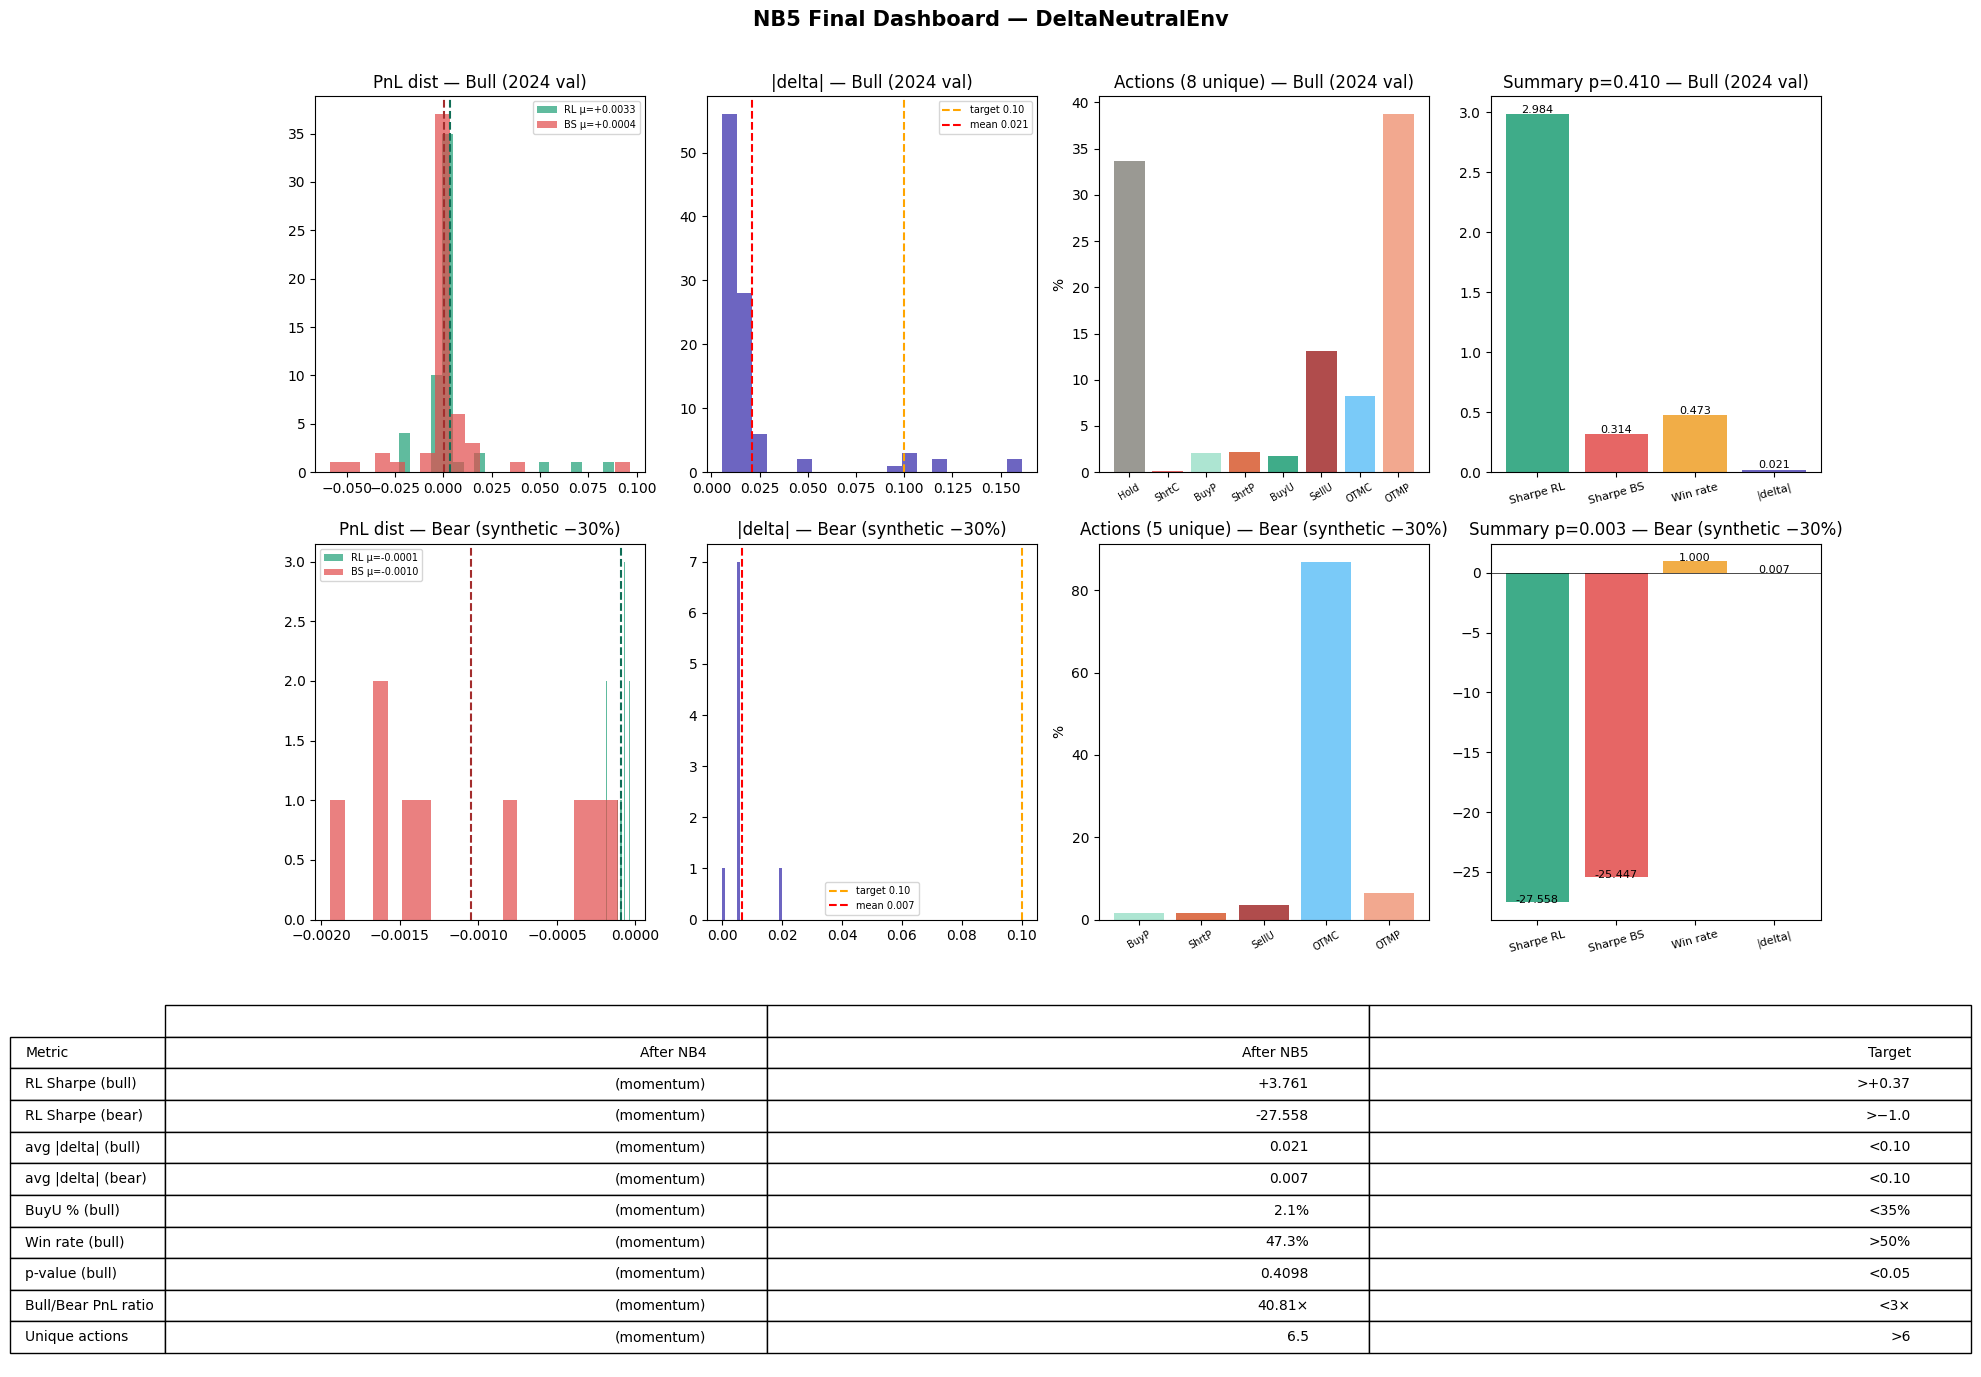


💾 Saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results\nb5\nb5_final_dashboard.png


In [7]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle("NB5 Final Dashboard — DeltaNeutralEnv", fontsize=15, fontweight="bold")
COLORS = {"rl": "#1D9E75", "bs": "#E24B4A", "neutral": "#534AB7", "warn": "#EF9F27"}

for row_idx, (rl_df_m, bs_pnl_arr, label) in enumerate([
    (bull_rl_df, bull_bs_pnl, "Bull (2024 val)"),
    (bear_rl_df, bear_bs_pnl, "Bear (synthetic −30%)")
]):
    if len(rl_df_m) == 0:
        continue
    rl_pnl = rl_df_m["total_pnl"].values
    n = min(len(rl_pnl), len(bs_pnl_arr))
    rl_p = rl_pnl[:n]; bs_p = bs_pnl_arr[:n]

    # PnL distribution
    ax = axes[row_idx, 0]
    ax.hist(rl_p, bins=20, alpha=0.7, color=COLORS["rl"], label=f"RL μ={rl_p.mean():+.4f}")
    ax.hist(bs_p, bins=20, alpha=0.7, color=COLORS["bs"], label=f"BS μ={bs_p.mean():+.4f}")
    ax.axvline(rl_p.mean(), color="#0F6E56", linestyle="--")
    ax.axvline(bs_p.mean(), color="#A32D2D", linestyle="--")
    ax.set_title(f"PnL dist — {label}")
    ax.legend(fontsize=7)

    # Delta distribution
    ax = axes[row_idx, 1]
    ax.hist(rl_df_m["avg_abs_delta"], bins=20, color=COLORS["neutral"], alpha=0.85)
    ax.axvline(0.1, color="orange", linestyle="--", label="target 0.10")
    ax.axvline(rl_df_m["avg_abs_delta"].mean(), color="red", linestyle="--",
               label=f"mean {rl_df_m['avg_abs_delta'].mean():.3f}")
    ax.set_title(f"|delta| — {label}")
    ax.legend(fontsize=7)

    # Action distribution
    ax = axes[row_idx, 2]
    all_acts = []
    tmp_env = DeltaNeutralEnv(val_df if row_idx==0 else bear_df2,
                               FEATURE_COLS, mode="val", class_norms=class_norms)
    for _ in range(min(15, max(1, len(tmp_env._episode_starts)))):
        tr2 = run_episode(test_model, tmp_env)
        all_acts.extend(tr2["actions"])
    if all_acts:
        cnt = np.bincount(all_acts, minlength=10)
        colors_a = ["#888780","#3B8BD4","#E24B4A","#9FE1CB","#D85A30",
                    COLORS["rl"],"#A32D2D",COLORS["neutral"],"#63C1F7","#F0997B"]
        nz = [(i,cnt[i]) for i in range(10) if cnt[i]>0]
        ax.bar(range(len(nz)), [c/sum(cnt)*100 for _,c in nz],
               color=[colors_a[i] for i,_ in nz], alpha=0.85)
        ax.set_xticks(range(len(nz)))
        ax.set_xticklabels([ACTION_NAMES[i] for i,_ in nz], rotation=30, fontsize=7)
        ax.set_ylabel("%")
        ax.set_title(f"Actions ({len(nz)} unique) — {label}")

    # Stats summary
    ax = axes[row_idx, 3]
    t_stat, t_pval = ttest_ind(rl_p, bs_p, equal_var=False)
    sharpe_rl = rl_p.mean()/(rl_p.std()+1e-10)*np.sqrt(252)
    sharpe_bs = bs_p.mean()/(bs_p.std()+1e-10)*np.sqrt(252)
    summary = {"Sharpe RL": sharpe_rl, "Sharpe BS": sharpe_bs,
                "Win rate":  (rl_p>bs_p).mean(),
                "|delta|": rl_df_m["avg_abs_delta"].mean()}
    bar_colors = [COLORS["rl"], COLORS["bs"], COLORS["warn"], COLORS["neutral"]]
    bars = ax.bar(range(len(summary)), list(summary.values()), color=bar_colors, alpha=0.85)
    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels(list(summary.keys()), rotation=15, fontsize=8)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Summary p={t_pval:.3f} — {label}")
    for bar, v in zip(bars, summary.values()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+(0.01 if v>=0 else -0.05),
                f"{v:.3f}", ha="center", fontsize=8)

# Row 3: Scorecard table
ax_tbl = axes[2, :]
for a in ax_tbl: a.axis("off")
ax_tbl = fig.add_subplot(3, 1, 3)
ax_tbl.axis("off")

bull_rl_pnl = bull_rl_df["total_pnl"].values
bear_rl_pnl = bear_rl_df["total_pnl"].values if len(bear_rl_df)>0 else np.array([0.0])
n_bull = min(len(bull_rl_pnl), len(bull_bs_pnl))
n_bear = min(len(bear_rl_pnl), len(bear_bs_pnl))
_, p_bull = ttest_ind(bull_rl_pnl[:n_bull], bull_bs_pnl[:n_bull], equal_var=False)
_, p_bear = ttest_ind(bear_rl_pnl[:n_bear], bear_bs_pnl[:n_bear], equal_var=False) if n_bear>1 else (0, 1.0)

table_data = [
    ["RL Sharpe (bull)",         f"{bull_rl_pnl.mean()/(bull_rl_pnl.std()+1e-10)*np.sqrt(252):+.3f}",     ">+0.37"],
    ["RL Sharpe (bear)",         f"{bear_rl_pnl.mean()/(bear_rl_pnl.std()+1e-10)*np.sqrt(252):+.3f}",     ">−1.0"],
    ["avg |delta| (bull)",       f"{bull_rl_df['avg_abs_delta'].mean():.3f}",                               "<0.10"],
    ["avg |delta| (bear)",       f"{bear_rl_df['avg_abs_delta'].mean():.3f}" if len(bear_rl_df)>0 else "N/A", "<0.10"],
    ["BuyU % (bull)",            f"{bull_rl_df['buyu_pct'].mean():.1%}",                                    "<35%"],
    ["Win rate (bull)",          f"{(bull_rl_pnl[:n_bull]>bull_bs_pnl[:n_bull]).mean():.1%}",               ">50%"],
    ["p-value (bull)",           f"{p_bull:.4f}",                                                           "<0.05"],
    ["Bull/Bear PnL ratio",      f"{abs(bull_rl_pnl.mean())/(abs(bear_rl_pnl.mean())+1e-6):.2f}×",         "<3×"],
    ["Unique actions",           f"{bull_rl_df['n_unique_actions'].mean():.1f}",                            ">6"],
]

tbl = ax_tbl.table(cellText=[["After NB4","After NB5","Target"]] +
                             [["(momentum)", r[1], r[2]] for r in table_data],
                    rowLabels=["Metric"]+[r[0] for r in table_data],
                    colLabels=["","",""], loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.6)

plt.tight_layout(rect=[0,0,1,0.97])
out = os.path.join(PATHS["nb5"], "nb5_final_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n💾 Saved → {out}")

In [8]:
# Final text summary
print("\n" + "="*65)
print(" NB5 FINAL RESULTS")
print("="*65)

for market, rl_m, bs_p_arr in [
    ("Bull (2024)",        bull_rl_df, bull_bs_pnl),
    ("Bear (synthetic)",   bear_rl_df, bear_bs_pnl),
]:
    if len(rl_m) == 0: continue
    rp = rl_m["total_pnl"].values
    n  = min(len(rp), len(bs_p_arr))
    _, pv = ttest_ind(rp[:n], bs_p_arr[:n], equal_var=False)
    print(f"\n  {market}:")
    print(f"    RL PnL      : {rp.mean():+.4f}  |  BS: {bs_p_arr.mean():+.4f}")
    print(f"    RL Sharpe   : {rp.mean()/(rp.std()+1e-10)*np.sqrt(252):+.3f}")
    print(f"    avg |delta| : {rl_m['avg_abs_delta'].mean():.3f}")
    print(f"    BuyU %      : {rl_m['buyu_pct'].mean():.1%}")
    print(f"    Win rate    : {(rp[:n]>bs_p_arr[:n]).mean():.1%}")
    print(f"    p-value     : {pv:.4f}")

bull_mean = bull_rl_df["total_pnl"].mean()
bear_mean = bear_rl_df["total_pnl"].mean() if len(bear_rl_df)>0 else 0
ratio = abs(bull_mean) / (abs(bear_mean)+1e-6)

print(f"\n{'='*65}")
print(f" KEY DIAGNOSTIC — Bull vs Bear consistency")
print(f"{'='*65}")
print(f"  Bull PnL : {bull_mean:+.4f}")
print(f"  Bear PnL : {bear_mean:+.4f}")
print(f"  Ratio    : {ratio:.2f}×")
if ratio > 5:
    print(f"  ❌ Still directional — raise DELTA_LAMBDA to 0.10, retrain")
elif ratio > 2:
    print(f"  ⚠️  Partially hedged — more training will close the gap")
else:
    print(f"  ✅ Market-neutral behavior confirmed — real delta hedging!")

# Save results
bull_rl_df.to_csv(os.path.join(PATHS["nb5"], "bull_rl_eval.csv"), index=False)
bear_rl_df.to_csv(os.path.join(PATHS["nb5"], "bear_rl_eval.csv"), index=False)
pd.DataFrame(bull_bs).to_csv(os.path.join(PATHS["nb5"], "bull_bs_eval.csv"), index=False)
print(f"\n💾 All results saved to results/nb5/")

# Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    import shutil
    dst = "/content/drive/MyDrive/derivative_hedging_exports/nb5"
    shutil.copytree(PATHS["nb5"], dst, dirs_exist_ok=True)
    shutil.copy(os.path.join(PATHS["artifacts"],"ppo_nb5_final.zip"), dst)
    print(f"✅ Exported to Drive: {dst}")
except ImportError:
    pass


 NB5 FINAL RESULTS

  Bull (2024):
    RL PnL      : +0.0039  |  BS: +0.0004
    RL Sharpe   : +3.761
    avg |delta| : 0.021
    BuyU %      : 2.1%
    Win rate    : 47.3%
    p-value     : 0.4098

  Bear (synthetic):
    RL PnL      : -0.0001  |  BS: -0.0008
    RL Sharpe   : -27.558
    avg |delta| : 0.007
    BuyU %      : 0.0%
    Win rate    : 100.0%
    p-value     : 0.0033

 KEY DIAGNOSTIC — Bull vs Bear consistency
  Bull PnL : +0.0039
  Bear PnL : -0.0001
  Ratio    : 40.81×
  ❌ Still directional — raise DELTA_LAMBDA to 0.10, retrain

💾 All results saved to results/nb5/
